<h3 style = "color:green">Introduction

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">This Exploratory Data Analysis (EDA) project examines the Global YouTube Statistics 2023 dataset to uncover trends and patterns among the world's most influential YouTube channels. The analysis focuses on key metrics such as subscriber count, video views, uploads, earnings, channel categories, and geographical distribution. By exploring these variables through data cleaning, visualization, and statistical summaries, the project aims to provide insights into content creation trends, audience engagement, and the factors associated with channel popularity and growth on YouTube.

<h3 style = "color:green">Objective

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">The primary objective of this project is to analyze the Global YouTube Statistics 2023 dataset and identify meaningful patterns in channel performance, content categories, and regional representation. Through exploratory data analysis, the project seeks to answer questions related to subscriber growth, viewership trends, content productivity, and the distribution of top-performing channels across different countries and niches.

In [1]:
import pandas as pd
import numpy as np
import polars as pl

from pandas import Series, DataFrame

import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so

<h3 style = "color:green">1. Getting ready with Data

In [2]:
data = pl.read_csv('/home/kartika/Datasets/Global YouTube Statistics.csv', encoding = 'latin1',ignore_errors = True)
data = data.to_pandas()

data.head()

,rank,Youtuber,subscribers,video views,category,Title,uploads,Country,Abbreviation,channel_type,...,subscribers_for_last_30_days,created_year,created_month,created_date,Gross tertiary education enrollment (%),Population,Unemployment rate,Urban_population,Latitude,Longitude
0,1,T-Series,245000000,2.280000e+11,Music,T-Series,20082,India,IN,Music,...,2000000,2006.0,Mar,13.0,28.1,1366417754,5.36,471031528,20.593684,78.96288
1,2,YouTube Movies,170000000,0.000000e+00,Film & Animation,youtubemovies,1,United States,US,Games,...,nan,2006.0,Mar,5.0,88.2,328239523,14.7,270663028,37.09024,-95.712891
2,3,MrBeast,166000000,2.836884e+10,Entertainment,MrBeast,741,United States,US,Entertainment,...,8000000,2012.0,Feb,20.0,88.2,328239523,14.7,270663028,37.09024,-95.712891
3,4,Cocomelon - Nursery Rhymes,162000000,1.640000e+11,Education,Cocomelon - Nursery Rhymes,966,United States,US,Education,...,1000000,2006.0,Sep,1.0,88.2,328239523,14.7,270663028,37.09024,-95.712891
4,5,SET India,159000000,1.480000e+11,Shows,SET India,116536,India,IN,Entertainment,...,1000000,2006.0,Sep,20.0,28.1,1366417754,5.36,471031528,20.593684,78.96288


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 995 entries, 0 to 994
Data columns (total 28 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   rank                                     995 non-null    int64  
 1   Youtuber                                 995 non-null    object 
 2   subscribers                              995 non-null    int64  
 3   video views                              995 non-null    float64
 4   category                                 995 non-null    object 
 5   Title                                    995 non-null    object 
 6   uploads                                  995 non-null    int64  
 7   Country                                  995 non-null    object 
 8   Abbreviation                             995 non-null    object 
 9   channel_type                             995 non-null    object 
 10  video_views_rank                         994 non-n

<div style = "background-color:lightblue; color:green; font-size:20px">No null values.

In [4]:
data.duplicated().sum()

np.int64(0)

<div style = "background-color:lightblue; color:green; font-size:20px">No duplicates values.

<div>

<div>

<h3 style = "color:green">2. Univariate Analysis

<h3 style = "color:green">2.1 Subscribers Distribution

In [5]:
data['subscribers'].describe()

count    9.950000e+02
mean     2.298241e+07
std      1.752611e+07
min      1.230000e+07
25%      1.450000e+07
50%      1.770000e+07
75%      2.460000e+07
max      2.450000e+08
Name: subscribers, dtype: float64

In [6]:
data['subscribers'].skew()

np.float64(5.513642744403962)

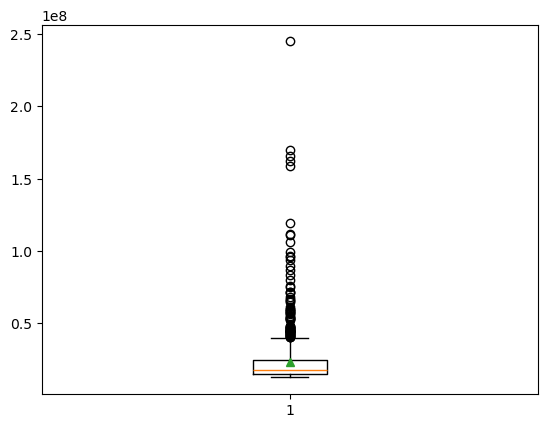

In [7]:
plt.boxplot(data['subscribers'], showmeans = True, )

plt.show()

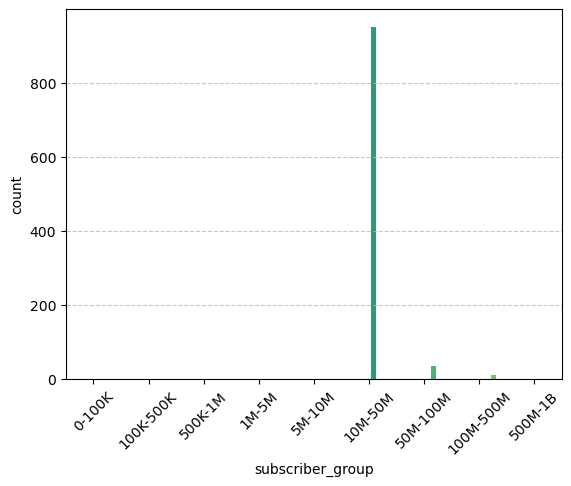

In [8]:
bins = [0, 100000, 500000, 1000000, 5000000,
        10000000, 50000000, 100000000,
        500000000, 1000000000]

labels = ['0-100K', '100K-500K', '500K-1M',
          '1M-5M', '5M-10M', '10M-50M',
          '50M-100M', '100M-500M', '500M-1B']

data['subscriber_group'] = pd.cut(
    data['subscribers'],
    bins=bins,
    labels=labels
)

sns.countplot(data=data, x='subscriber_group', hue = 'subscriber_group', palette = 'viridis')
plt.grid(axis = 'y', linestyle = '--', alpha = 0.7)
plt.xticks(rotation=45)
plt.show()

In [9]:
print(data['subscriber_group'].value_counts())

subscriber_group
10M-50M      951
50M-100M      35
100M-500M      9
0-100K         0
100K-500K      0
5M-10M         0
1M-5M          0
500K-1M        0
500M-1B        0
Name: count, dtype: int64


<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">In top 1000 youtubers, 951 which is nearly 96% have subscribers between 10M-50M and rest 44 youtubers have subscribers >50M. Due to which the distribution is highly positively skewed, many youtubers have comparatively low subscribers, whereas top youtubers account for astronomical number of subscribers.

<div>

<h3 style = "color:green">2.2 Video views

In [10]:
data['video views'].describe()

count    9.950000e+02
mean     1.103954e+10
std      1.411084e+10
min      0.000000e+00
25%      4.288145e+09
50%      7.760820e+09
75%      1.355470e+10
max      2.280000e+11
Name: video views, dtype: float64

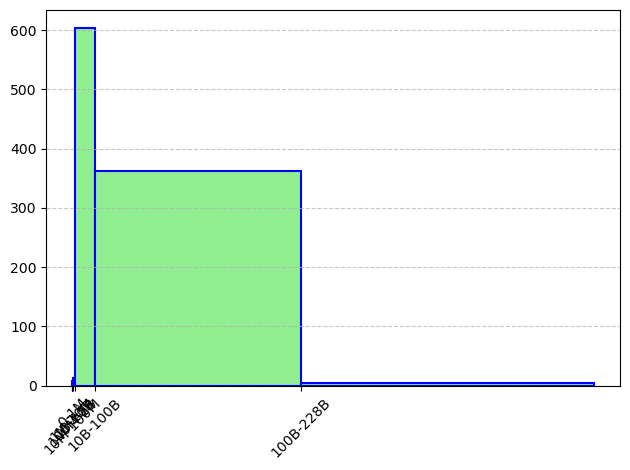

In [11]:
bins = [0, 1e6, 1e7, 1e8, 1e9, 1e10, 1e11, 2.28e11]
labels = ['0-1M', '1M-10M', '10M-100M', '100M-1B', '1B-10B', '10B-100B', '100B-228B']

plt.hist(data['video views'],bins = bins,color = 'lightgreen', linewidth = 1.5, edgecolor = 'blue')
plt.grid(axis = 'y', linestyle = '--', alpha = 0.7)


plt.xticks(bins[:-1], labels,rotation=45)
plt.tight_layout()
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Video views of youtubers is also positively skewed. Most of the top youtubers around 60% are getting views around 10B. While, nearly 35% of the youtubers are getting views in range 10B-100B, which is a wide range. But, rest 5% of the youtubers are getting views >100B, which acts as outlier in this distribution.

<div>

<div>

<h3 style = "color:green">2.3 Content Category

In [12]:
data['category'].value_counts()

category
Entertainment            241
Music                    202
People & Blogs           132
Gaming                    94
Comedy                    69
Film & Animation          46
nan                       46
Education                 45
Howto & Style             40
News & Politics           26
Science & Technology      17
Shows                     13
Sports                    11
Pets & Animals             4
Trailers                   2
Nonprofits & Activism      2
Movies                     2
Autos & Vehicles           2
Travel & Events            1
Name: count, dtype: int64

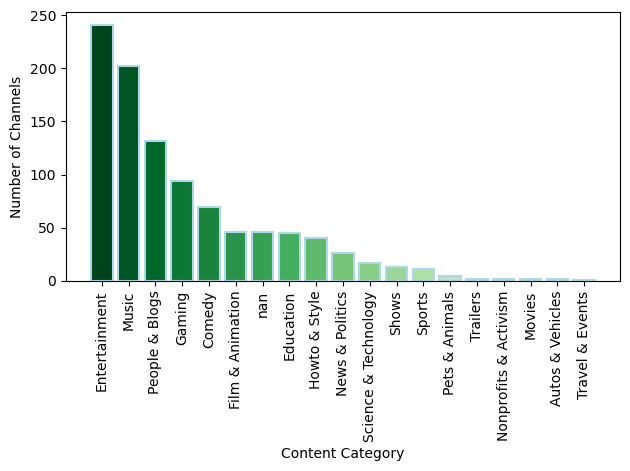

In [13]:
plt.bar(data['category'].value_counts().index, data['category'].value_counts().values,
         color = plt.cm.Greens(np.linspace(1, 0, len(data['category'].value_counts()))), edgecolor = 'lightblue', linewidth = 1.5)


plt.xticks(data['category'].value_counts().index, rotation=90)
plt.xlabel('Content Category')
plt.ylabel('Number of Channels')
plt.tight_layout()
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">
<ul>
<li>
Categories like Entertainment, Music, and People & Blogs have the highest number of channels.
This suggests that content creation on YouTube is heavily concentrated in general entertainment and lifestyle-oriented content.</li>
<li>Comedy, Film & Animation, and Education form a second tier.
These categories have substantial representation but are noticeably smaller than the leading categories.
</li>
<li>
Categories such as Sports, Pets & Animals, Travel & Events, Autos & Vehicles, and Nonprofits & Activism have very few channels.
The distribution is highly skewed, with a handful of categories accounting for most channels
</li>

<div>

<h3 style = "color:green">2.4 Uploads

In [14]:
data['uploads'].describe()

count       995.000000
mean       9187.125628
std       34151.352254
min           0.000000
25%         194.500000
50%         729.000000
75%        2667.500000
max      301308.000000
Name: uploads, dtype: float64

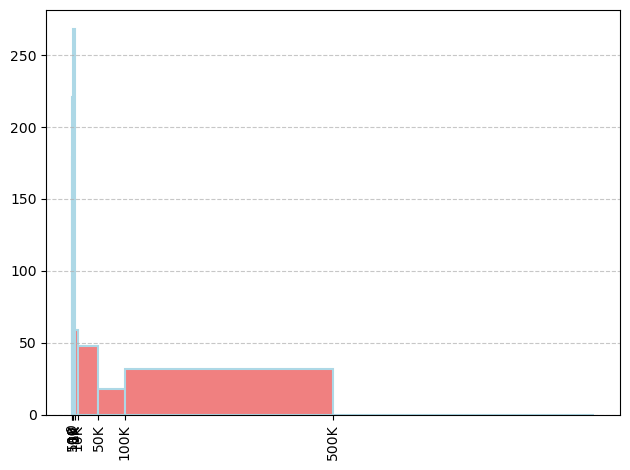

In [15]:
bins = [0, 100, 500, 1000, 5000, 10000, 50000, 100000, 500000, 1000000]
labels = ['0', '100', '500', '1K', '5K', '10K', '50K', '100K', '500K']

plt.hist(data['uploads'], bins=bins, color='lightcoral', edgecolor='lightblue', linewidth=1.5)

plt.xticks(bins[:-1], labels, rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">The number of uploads of top youtube channels has positive skewed distribution. 50% of the youtubers have uploads less than 1K videos. 75% of the youtubers have uploads less than 3K. Rest, percentage of youtubers have uploads >50K.

<div>

<h3 style = "color:green">2.5 Country Representation

In [16]:
data['Country'].value_counts()

Country
United States           313
India                   168
nan                     122
Brazil                   62
United Kingdom           43
Mexico                   33
Indonesia                28
Spain                    22
Thailand                 18
South Korea              17
Russia                   16
Canada                   15
Argentina                13
Philippines              12
Colombia                 11
Saudi Arabia              9
Australia                 9
Ukraine                   8
United Arab Emirates      7
Pakistan                  6
Germany                   6
France                    5
Japan                     5
Turkey                    4
Sweden                    4
Chile                     3
Jordan                    3
Netherlands               3
Vietnam                   3
Singapore                 3
Ecuador                   2
Egypt                     2
Iraq                      2
Italy                     2
Barbados                  1
El Salvador 

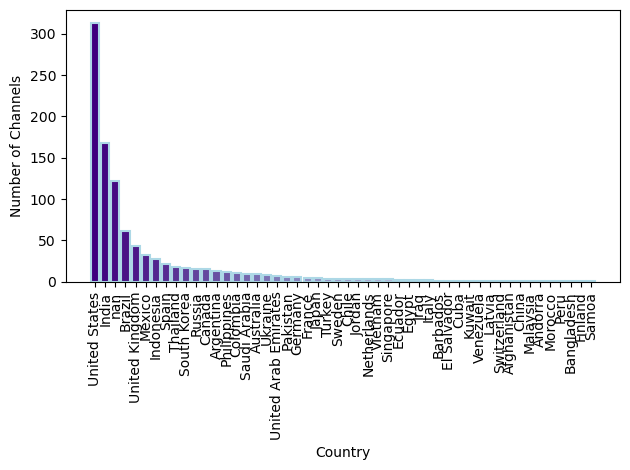

In [17]:
plt.bar(data['Country'].value_counts().index, data['Country'].value_counts().values,
         color = plt.cm.Purples(np.linspace(1, 0, len(data['Country'].value_counts()))), edgecolor = 'lightblue', linewidth = 1.5)

plt.xticks(data['Country'].value_counts().index, rotation=90)
plt.xlabel('Country')
plt.ylabel('Number of Channels')
plt.tight_layout()
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Country wise, USA accounts for most number of top channels, with 313 youtubers in top 1000. It is followed by India with 168 youtubers. Other countries, shows consistent decreasing trend in numbers of youtubers compared to these two countries.

<div>

<h3 style = "color:green">2.6 Last 30 days Video Views

In [23]:
data['video_views_for_the_last_30_days'] = data['video_views_for_the_last_30_days'].replace('nan', value = 0)
data['video_views_for_the_last_30_days'] = data['video_views_for_the_last_30_days'].astype(int)

In [24]:
data['video_views_for_the_last_30_days'].describe()

count    9.950000e+02
mean     1.657267e+08
std      4.065010e+08
min      0.000000e+00
25%      1.351700e+07
50%      5.635800e+07
75%      1.585655e+08
max      6.589000e+09
Name: video_views_for_the_last_30_days, dtype: float64

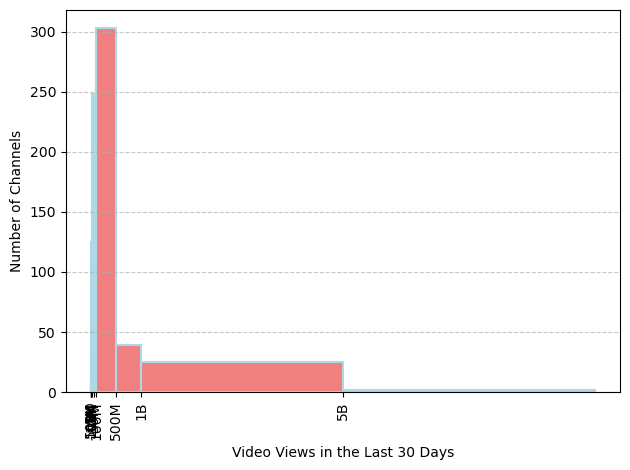

In [29]:
bins = [0, 1000, 10000, 100000, 500000, 1000000, 5000000, 10000000, 50000000,
         100000000, 500000000, 1000000000, 5000000000, 10000000000]
labels = ['0', '1K', '10K', '100K', '500K', '1M','5M', 
           '10M', '50M', '100M', '500M', '1B', '5B']

plt.hist(data['video_views_for_the_last_30_days'], bins=bins, color='lightcoral', edgecolor='lightblue', linewidth=1.5, rwidth = 1)

plt.xlabel('Video Views in the Last 30 Days')
plt.ylabel('Number of Channels')
plt.xticks(bins[:-1], labels, rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">On average, the top youtubers got around 165M views last month. There are very few number of youtubers who are getting over billion views monthly.

<div>

<h3 style = "color:green">2.7 Last 30 days subscribers gained

In [33]:
data['subscribers_for_last_30_days'] = data['subscribers_for_last_30_days'].replace('nan', value = 0)
data['subscribers_for_last_30_days'] = data['subscribers_for_last_30_days'].astype(int)
data['subscribers_for_last_30_days'].describe()

count    9.950000e+02
mean     2.308483e+05
std      5.261092e+05
min      0.000000e+00
25%      0.000000e+00
50%      1.000000e+05
75%      2.000000e+05
max      8.000000e+06
Name: subscribers_for_last_30_days, dtype: float64

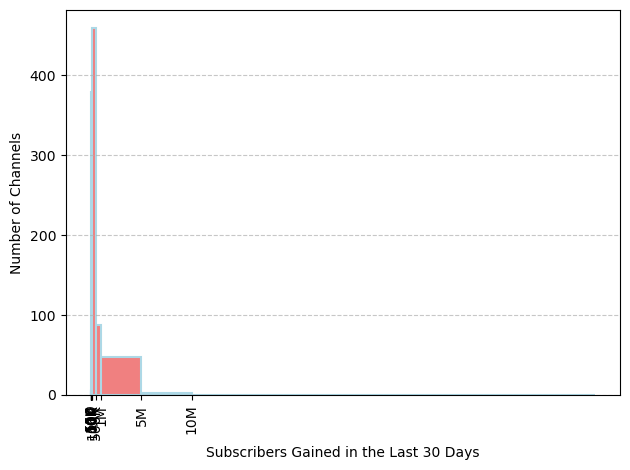

In [35]:
bins = [0, 100, 500, 1000, 5000, 10000, 50000, 100000, 500000, 1000000, 5000000, 10000000, 50000000]
labels = ['0', '100', '500', '1K', '5K', '10K', '50K', '100K', '500K', '1M', '5M', '10M']

plt.hist(data['subscribers_for_last_30_days'], bins=bins, color='lightcoral', edgecolor='lightblue', linewidth=1.5, rwidth = 1)

plt.xlabel('Subscribers Gained in the Last 30 Days')
plt.ylabel('Number of Channels')
plt.xticks(bins[:-1], labels, rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">On average the youtubers gained 230K subscribers last month. This distribution is also positively skewed, as in top 1000 most of the youtubers gained subscribers around average and few gained over million subscribers.

<div>

<div>

<h3 style = "color:green">2.8